# This is a notebook for querying the Beacon SeaDataNet CDI instance (datalake subsetting API)
-   You can run each cell individually by pressing "shift + enter".
-   For more information, questions, bugs, please contact us [info@maris.nl](mailto:info@maris.nl)

#### Install the required packages, if you have not already installed them in your environment:

-   `pip install -r requirements_seadatanet.txt`

In [ ]:
import requests
import json
import pandas as pd
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from SPARQLWrapper import SPARQLWrapper, JSON

In [ ]:
Token = "To request a token, contact paul at maris.nl -> maris.nl/contact"

#### Retrieve the available columns from the SeaDataNet CDI endpoint

Swagger page here: https://beacon-cdi.maris.nl/swagger/


In [3]:
responseinfo = requests.get("https://beacon-cdi.maris.nl/api/query/available-columns",headers={"Authorization": f"Bearer {Token}"},)
params = responseinfo.json()
with open("params.txt", "w") as f:
    for field in params:
        f.write(field + "\n")

In [4]:
# EXV Input
exv_code = "EXV017"
mindate = "2000-01-01"  # yyyy-mm-dd
maxdate = "2020-01-01"  # yyyy-mm-dd
minlon = 2
maxlon = 6
minlat = 52
maxlat = 54
mindepth = 0
maxdepth = 10

In [5]:
def EXV_iadopt(exv_code):
    # SPARQL endpoint
    endpoint_url = "https://vocab.nerc.ac.uk/sparql/sparql"

    # Construct full identifier
    exv_identifier = f"SDN:EXV::{exv_code}"

    # Create the query with the user input
    sparql_query = f"""
    PREFIX dce: <http://purl.org/dc/elements/1.1/>
    PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
    PREFIX iadopt: <https://w3id.org/iadopt/ont#> 
    PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>

    SELECT DISTINCT ?p01 ?prefLabel ?notation
    WHERE {{
      ?exv a skos:Concept .
      ?exv dce:identifier "{exv_identifier}" .

      OPTIONAL {{?exv iadopt:hasApplicableMatrix ?matrix .}}
      ?exv iadopt:hasApplicableObjectOfInterest ?ooi .
      ?exv iadopt:hasApplicableProperty ?property .

      <http://vocab.nerc.ac.uk/collection/P01/current/> skos:member ?p01 .

      OPTIONAL {{ ?p01 iadopt:hasMatrix ?matrix . }}
      ?p01 iadopt:hasObjectOfInterest ?ooi .
      ?p01 iadopt:hasProperty ?property .

      OPTIONAL {{ ?p01 skos:prefLabel ?prefLabel . }}
      OPTIONAL {{ ?p01 skos:notation ?notation . }}
    }}
    """

    # Set up the SPARQL request
    sparql = SPARQLWrapper(endpoint_url)
    sparql.setQuery(sparql_query)
    sparql.setReturnFormat(JSON)

    # Run the query and parse results
    results = sparql.query().convert()

    codes = []

    # Show results
    for result in results["results"]["bindings"]:
        uri = result.get("p01", {}).get("value", "")
        codes.append(uri.rstrip("/").split("/")[-1])

    matching_p01s = []

    for code in codes:
        if code in params:
            matching_p01s.append(code)

    return matching_p01s

matching_p01s = EXV_iadopt(exv_code)
print(matching_p01s)

['PSSTRT01', 'TEMPST01', 'TEMPPR01', 'TEMPCU01', 'TEMPHU01', 'TEMPHG02', 'TEMPCC02', 'TEMPHG01', 'TEMPRTNX', 'TEMPHGNX', 'TMCLCCI1', 'TEMPDTNX', 'TEMPET01', 'TEMPTC01', 'TEMPMT01', 'TEMPCC01', 'TEMPSU01', 'TEMPBT01', 'TMCLCCL1', 'PSSTTS01', 'TEMPSZ01', 'TEMPTC02', 'TEMPHU02', 'TEMPCU02', 'TEMPST02', 'TEMPS601', 'TEMPP901', 'TEMPS901']


#### This will create the query body based on your input parameters, you can add other "query_parameters" and "filters" to suit your needs.

-   For more query examples and explanations, you can take a look at https://maris-development.github.io/beacon/.


In [6]:
def query(mindate, maxdate, minlon, maxlon, minlat, maxlat, mindepth, maxdepth, matching_p01s: list[str]):
    query_parameters = []
    query_parameters.append("LONGITUDE")
    query_parameters.append("LATITUDE")
    query_parameters.append("TIME")
    query_parameters.append({"function": "coalesce", "args": ["DEPTH", "PRES"], "alias": "DEPTH"})
    query_parameters.append("SDN_STATION")
    query_parameters.append("SDN_EDMO_CODE")
    query_parameters.append("SDN_LOCAL_CDI_ID")
    for p01 in matching_p01s:
        query_parameters.append(p01)

    filters = []
    filters.append({"for_query_parameter": "TIME", "min": f"{mindate}T00:00:00", "max": f"{maxdate}T00:00:00"})
    filters.append({"for_query_parameter": "DEPTH", "min": mindepth, "max": maxdepth})
    filters.append({"for_query_parameter": "LONGITUDE", "min": minlon, "max": maxlon})
    filters.append({"for_query_parameter": "LATITUDE", "min": minlat, "max": maxlat})


    parameter_or_filters = []
    for p01 in matching_p01s:
        parameter_or_filters.append({"is_not_null": {"for_query_parameter": p01}})
    or_filter = {
        "or" : parameter_or_filters
    }
    filters.append(or_filter)
    body = {
        "query_parameters": query_parameters,
        "filters": filters,
        "output": {"format": "ipc"},
    }
    return body

query_body = query(mindate, maxdate, minlon, maxlon, minlat, maxlat, mindepth, maxdepth, matching_p01s)

#### This is the post request that is sent to Beacon with the above specified body.


In [7]:
response = requests.post("https://beacon-cdi.maris.nl/api/query", json.dumps(query_body),
    headers={"Authorization": f"Bearer {Token}",
             "Content-type": "application/json"})

if response.status_code == 204:
    print("No data has been found for your query, please update your input fields above and run the notebook again.")
elif response.status_code != 200:
    print(response.text)

In [8]:
pd.set_option('display.max_columns', None)
regionname = f"[{minlat},{minlon}],[{maxlat},{maxlon}]"

if not os.path.exists("./Beacon_V1.0.0_Output"):
    os.makedirs("Beacon_V1.0.0_Output")

open(f"./Beacon_V1.0.0_Output/SeaDataNet_{exv_code}_{regionname}_{mindate}-{maxdate}_[{mindepth}-{maxdepth}m].arrow", "wb",).write(response.content);

In [9]:
df = pd.read_feather(f"./Beacon_V1.0.0_Output/SeaDataNet_{exv_code}_{regionname}_{mindate}-{maxdate}_[{mindepth}-{maxdepth}m].arrow")
df = df.set_index("TIME").sort_index() 
cols_to_exclude = ['SDN_STATION', 'SDN_EDMO_CODE', 'SDN_LOCAL_CDI_ID']
df[df.columns.difference(cols_to_exclude)] = df[df.columns.difference(cols_to_exclude)].apply(pd.to_numeric, errors='coerce')
df[exv_code] = df[matching_p01s].mean(axis=1)
df.drop(columns=matching_p01s, inplace=True)
df

,LONGITUDE,LATITUDE,DEPTH,SDN_STATION,SDN_EDMO_CODE,SDN_LOCAL_CDI_ID,EXV017
TIME,,,,,,,
2000-01-01 12:00:00,4.789167,53.001667,0.0,NIOZ Jetty,630,monthly_ts_horntje,5.30
2000-01-04 20:33:00,4.622000,52.466000,0.0,ijmdn1,1526,ijmdn1-2000,9.10
2000-01-04 20:33:00,4.622000,52.466000,0.0,ijmdn1,1526,ijmdn1-2000,10.70
2000-01-04 20:33:00,4.622000,52.466000,0.0,ijmdn1,1526,ijmdn1-2000,18.70
2000-01-04 20:33:00,4.622000,52.466000,0.0,ijmdn1,1526,ijmdn1-2000,27.00
...,...,...,...,...,...,...,...
2019-08-29 06:12:59,4.000000,53.000000,5.0,0005,730,OCEAN_DF80D907-2570-4FF9-A502-D83EC6D9C6DA,19.11
2019-08-29 09:41:00,4.333300,52.500000,5.0,0006,730,OCEAN_6DAF5FC9-F3C3-410D-AA0A-0D270F88DB60,19.85
2019-08-29 14:47:00,3.733300,52.000000,5.0,0007,730,OCEAN_AE05C718-22B1-4CBD-802D-185BBCA017F6,19.86


In [10]:
highbound = 28
lowbound = -2
df = df.loc[(df[f"{exv_code}"] < highbound) & (df[f"{exv_code}"] > lowbound)]

#### Plotting of results


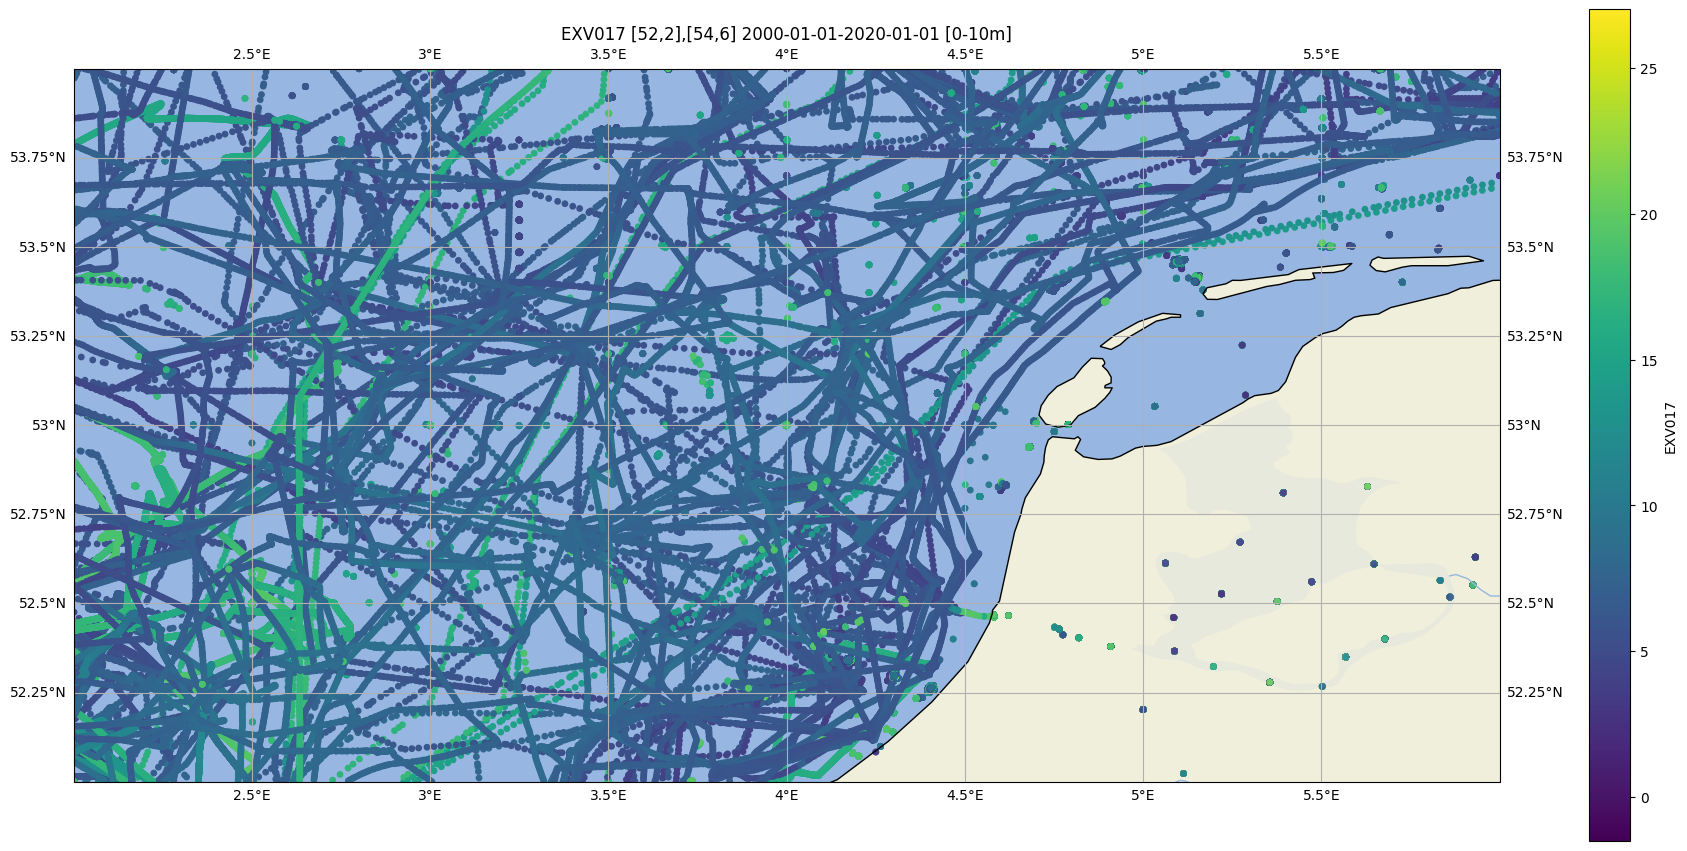

In [11]:
fig = plt.figure(figsize=(23, 18))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([minlon, maxlon, minlat, maxlat], crs=ccrs.PlateCarree())  # (west, east, south, north)

ax.coastlines(resolution="10m")
ax.gridlines(draw_labels=True)

sc = ax.scatter(df["LONGITUDE"], df["LATITUDE"], c = df[exv_code], cmap="viridis", s=15, transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.RIVERS)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.LAKES, alpha=0.1)

cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.6, label="Value Set 1")
cbar.set_label(f"{exv_code}")

plt.title(f"{exv_code} {regionname} {mindate}-{maxdate} [{mindepth}-{maxdepth}m]")

plt.show();

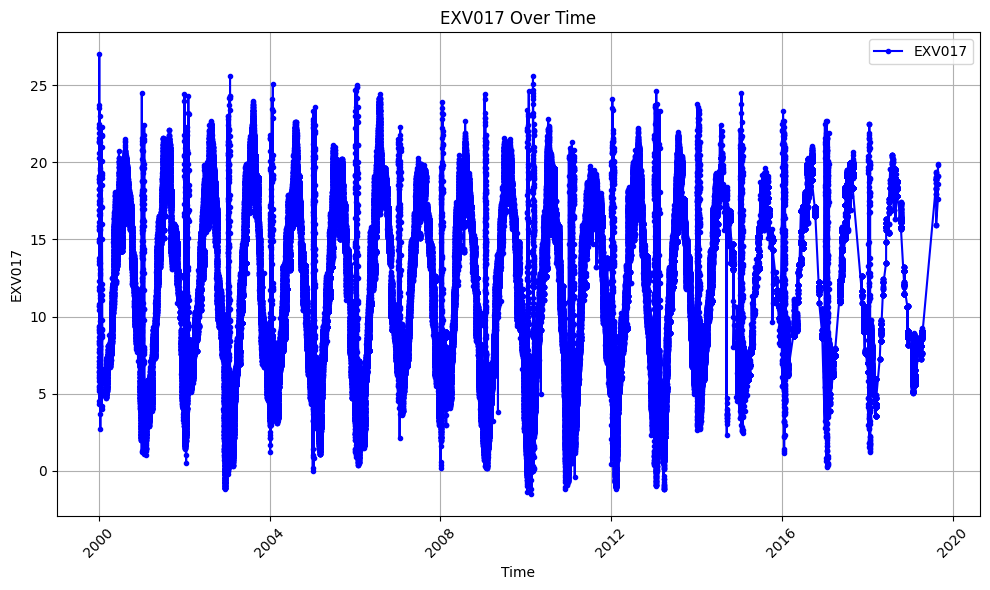

In [12]:
# Plotting the time series
plt.figure(figsize=(10, 6))  # Set figure size
plt.plot(df.index, df[exv_code], marker='.', color='b', label=f'{exv_code}')
plt.title(f'{exv_code} Over Time')
plt.xlabel('Time')
plt.ylabel(f'{exv_code}')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.grid(True)
plt.legend()

# Show plot
plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()